# Πρόβλημα 2: **Robust MNIST Classifier**

## Βάλτε τα στοιχεία σας!

Πριν προχωρήσετε στην άσκηση συμπληρώστε το username και το password σας που σας έχει δοθεί και τρέξτε αυτό το κελί. Αυτές οι πληροφορίες είναι απαραίτητες για να σας αναγνωρίσει ο server και να βαθμολογήσει τις λύσεις σας.

- **Ο τελικός σας βαθμός καθορίζεται μόνο από το ΤΕΛΕΥΤΑΙΟ ΜΟΝΤΕΛΟ ΠΟΥ ΥΠΟΒΛΗΘΗΚΕ.**
- **Βεβαιωθείτε ότι χρησιμοποιείτε τα σωστά διαπιστευτήρια, διαφορετικά η λύση σας δεν θα βαθμολογηθεί.**

Εάν η ταυτοποίηση αποτύχει, θα δείτε ένα μήνυμα σφάλματος κάτω από την κλήση του `submit_for_grading()` στο τελευταίο κελί

In [2]:
import requests
import os

SERVER_URL = "http://195.251.252.26:5000"

submission_data = {
    'username': 'contestant15',
    'password': 'dV3^m4FbX',
    'exercise': 'lab2_classification'
}

# The student must type the local name of this notebook file here if changed
NOTEBOOK_FILE = "/content/drive/MyDrive/Colab Notebooks/02_robust_mnist_classifier.ipynb"
## NOTEBOOK_FILE = "02_robust_mnist_classifier.ipynb"

FILE_CONFIG = {
    "lab2_classification": {
        "filename": "submission.csv",
        "mime": "text/csv"
    }
}

# Περιγραφή

Τα νευρωνικά δίκτυα (NN) γνώρισαν μεγάλη άνθηση τα τελευταία χρόνια, βρίσκοντας εφαρμογή σε πληθώρα επιστημονικών περιοχών. Παράλληλα με την έρευνα για την βελτίωση και την ανάπτυξη διαφορετικών αρχιτεκτονικών μελετάται και η ανθεκτικότητα (robustness) των NN.

Ειδικότερα, πρόσφατες εργασίες έδειξαν ότι πολλές αρχιτεκτονικές νευρωνικών δικτύων ταξινόμησης εικόνων είναι ιδιαίτερα ευάλωτες σε κακόβουλες επιθέσεις. Για παράδειγμα μπορεί κανείς να κατασκευάσει εικόνες που είναι σχεδόν πανομοιότυπες με πραγματικά δεδομένα, αλλά ταξινομούνται λανθασμένα από ένα νευρωνικό δίκτυο που έχει εκπαιδευτεί με τις παραδοσιακές μεθόδους.

## Στόχος

Ο στόχος της άσκησης είναι να εκπαιδεύσετε κατάλληλα ένα νευρωνικό δίκτυο που ταξινομεί ψηφία ώστε να παραμένει ανθεκτικό σε επιθέσεις, χωρίς να αλλάξετε την αρχιτεκτονική του. Πιο συγκεκριμένα, το μοντέλο σας, θα πρέπει να ταξινομεί σωστά όχι μόνο τις “καθαρές” εικόνες ψηφίων αλλά και “πειραγμένες” εκδοχές τους που έχουν παραχθεί από κάποιον κακόβουλο χρήστη (adversary).

# **Ξεκινήστε εδώ!**

## Εισαγωγή βασικών βιβλιοθηκών και αρχικοποιήσεις


In [3]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_num_threads(max(1, min(8, os.cpu_count() or 1)))
DEVICE = torch.device("cpu")
print("device:", DEVICE)
print("torch threads:", torch.get_num_threads())

device: cpu
torch threads: 2


## Εισαγωγή Δεδομένων

Για την εκπαίδευση του μοντέλου δίνονται καθαρές εικόνες ψηφίων από το σύνολο δεδομένων MNIST μαζί με τις αντίστοιχες ετικέτες τους. Κάθε εικόνα αποτελείται από pixels με τιμές στο διάστημα $[0,1]$.

Ένας adversary μπορεί να τροποποιήσει μια καθαρή εικόνα $X$ του MNIST dataset και να παράγει μια πειραγμένη εικόνα $Y$, με τους εξής περιορισμούς:

- κάθε pixel της εικόνας Y πρέπει να παραμένει στο [0,1]

- για κάθε pixel $Y_i$ της πειραγμένης εικόνας $Y$ και το αντίστοιχο pixel $X_i$ της αρχικής εικόνας $X$, πρέπει να ισχύει $|Y_i - X_i| \leq 0.3$

Με άλλα λόγια, κάθε pixel της “πειραγμένης” εικόνας μπορεί να αλλάξει το πολύ κατά $0.3$, χωρίς να βγει έξω από το επιτρεπτό διάστημα τιμών $[0,1]$.

In [4]:
import gdown
import os

folder_id = '1A_EEFt8Pnv8p2Ud9NHmmVkcopvfXAs0w'
url = f'https://drive.google.com/drive/folders/{folder_id}?usp=sharing'
output_directory = '.'

if not os.path.exists(output_directory):
    os.makedirs(output_directory)
gdown.download_folder(url, output=output_directory, quiet=False, remaining_ok=True)
print(f"Successfully downloaded data to {output_directory}")

Retrieving folder contents


Retrieving folder 1CAD_BEDuPBJWzDTAnXxQWlj-fCrgCLtz data
Processing file 1CrYCOvpzA624uznU-JE4FLKuNU4l3TC1 private_test_images.npy
Processing file 1hArpv5xoPMVsSkzkrL2n1q2lR9wuD6hA public_test_images.npy
Processing file 1dR1EbQNIyD9B1mKWcQoHM4Xu9xyl6AJ3 train_images.npy
Processing file 1qHLAqhYxPOv7qUllu8AKg3CXqfHKtCY2 train_labels.npy


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1CrYCOvpzA624uznU-JE4FLKuNU4l3TC1
To: /content/data/private_test_images.npy
100%|██████████| 784k/784k [00:00<00:00, 98.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hArpv5xoPMVsSkzkrL2n1q2lR9wuD6hA
To: /content/data/public_test_images.npy
100%|██████████| 235k/235k [00:00<00:00, 27.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dR1EbQNIyD9B1mKWcQoHM4Xu9xyl6AJ3
To: /content/data/train_images.npy
100%|██████████| 6.27M/6.27M [00:00<00:00, 209MB/s]
Downloading...
From: https://drive.google.com/uc?id=1qHLAqhYxPOv7qUllu8AKg3CXqfHKtCY2
To: /content/data/train_labels.npy
100%|██████████| 64.1k/64.1k [00:00<00:00, 32.9MB/s]

Successfully downloaded data to .



Download completed


In [5]:
x_train = torch.tensor(np.load("data/train_images.npy"), dtype=torch.float32) / 255.0
y_train = torch.tensor(np.load("data/train_labels.npy"), dtype=torch.long)

x_public_test = torch.tensor(np.load("data/public_test_images.npy"), dtype=torch.float32) / 255.0
x_private_test = torch.tensor(np.load("data/private_test_images.npy"), dtype=torch.float32) / 255.0

print("train:", tuple(x_train.shape), tuple(y_train.shape))
print("public test:", tuple(x_public_test.shape))
print("private test:", tuple(x_private_test.shape))

train: (8000, 1, 28, 28) (8000,)
public test: (300, 1, 28, 28)
private test: (1000, 1, 28, 28)


## Παραδείγματα εικόνων (καθαρών και πειραγμένων)

In [6]:
from torchvision import transforms as T

def randomize_img(x):
  np.random.seed(42)
  new = np.zeros((784))
  rand = np.array([np.random.random()*0.6 - 0.3 for _ in x.flatten()])
  x = x.view(-1).numpy()

  for i in range(len(rand)):
    # print(type(new), type(new[i]))
    # print(type(x), type(x[i]))
    # print(type(rand), type(rand[i]))
    new[i] = np.clip(x[i] + rand[i], 0, 1)
  return new

val = [np.random.random()*0.6 - 0.3 for _ in x_train[0].flatten()]
print(max(val), min(val))
val = randomize_img(x_train[0])
print(max(val), min(val))

0.2998989768163915 -0.2996540043341875
1.0 0.0


In [7]:
num = len(x_train)
x_noisy_set = torch.Tensor([randomize_img(x_train[i]) for i in range(num)]).reshape(num, 1, 28, 28)
# x_noisy_set = torch.Tensor([torch.Tensor([randomize_img(x_train[i]) for _ in range(3)]) for i in range(num)]).reshape(num, 1, 28, 28)

# x_noisy_set = T.Compose([
#     T.GaussianBlur(5),
#     T.ToTensor
# ])
print(x_noisy_set.shape)


torch.Size([8000, 1, 28, 28])


/tmp/ipykernel_42646/3319061511.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x_noisy_set = torch.Tensor([randomize_img(x_train[i]) for i in range(num)]).reshape(num, 1, 28, 28)


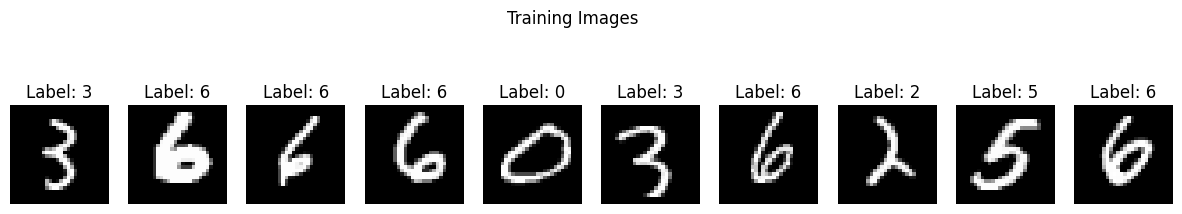

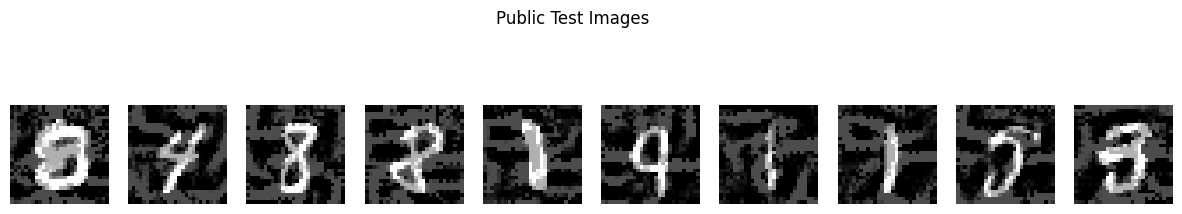

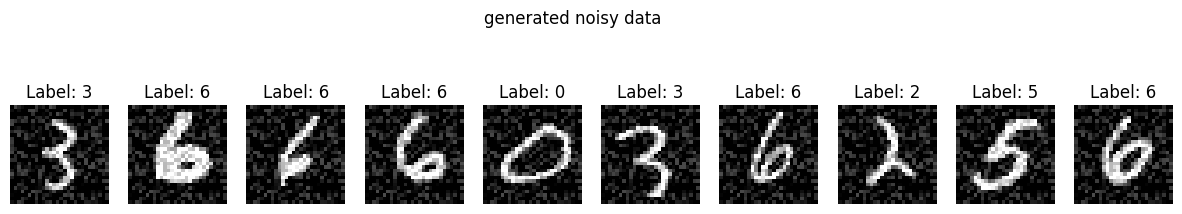

In [ ]:
import matplotlib.pyplot as plt

def plot_images(images, labels=None, title="Images", n=10):
    plt.figure(figsize=(15, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        if labels is not None:
            plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

plot_images(x_train, y_train, "Training Images")
plot_images(x_public_test, title="Public Test Images")
plot_images(x_noisy_set, y_train, title="generated noisy data")

## Αρχιτεκτονική του Μοντέλου

In [9]:
#########################################
#### DO NOT CHANGE THIS ARCHITECTURE ####
#########################################

class FixedMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.fc1 = nn.Linear(7 * 7 * 64, 1024)
        self.fc2 = nn.Linear(1024, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = FixedMNISTCNN().to(DEVICE) # dV3^m4FbX
print(model.parameters())

<generator object Module.parameters at 0x7a647d1fc740>


## Εκπαίδευση του μοντέλου

In [10]:
import torch
import copy
import torch.nn.functional as F
import matplotlib as plt

def train(model, train_loader, optimizer, epochs, criterion):
  device = "cpu"
  train_losses = []
  test_losses = []
  test_accuracies = []

  best_accuracy = 0
  best_model_wts = copy.deepcopy(model.state_dict())

  for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
      optimizer.zero_grad()
      outputs = model(batch_x)
      loss = criterion(outputs, batch_y)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    model.eval()
    total_test_loss = 0
    correct = 0
    total = 0

    # with torch.no_grad():
    #   for batch_x, batch_y in test_loader:
    #     outputs = model(batch_x)
    #     loss = criterion(outputs, batch_y)
    #     total_test_loss += loss.item()

    #     _, predicted = torch.max(outputs.data, 1)
    #     total += batch_y.size(0)
    #     correct += (predicted == batch_y).sum().item()

    # epoch_loss = total_test_loss / len(test_loader)
    # epoch_accuracy = correct / total
    # test_losses.append(epoch_loss)
    # test_accuracies.append(epoch_accuracy)

    # if epoch_accuracy > best_accuracy:
    #   best_accuracy = epoch_accuracy
    #   best_model_wts = copy.deepcopy(model.state_dict())
    #   best_epoch = epoch + 1

    print(
        f"epoch {epoch+1}/{epochs} "
        f"training loss: {train_losses[-1]}"
        # f"Testing Loss: {test_losses[-1]}"
        # f"Testing Accuracy: {epoch_accuracy:.4f}"
    )
    # model.load_state_dict(best_model_wts)
    # print(f"best epoch: {best_epoch} test acc: {best_accuracy}")


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch
train_clean_ds = TensorDataset(x_noisy_set, y_train)
dataloader = DataLoader(
    train_clean_ds,
    batch_size=512,
    num_workers=2,
    persistent_workers=True,
    shuffle=True
    )
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
train(model, dataloader, optimizer, 15, criterion) # 15

epoch 1/15 training loss: 2.293730318546295
epoch 2/15 training loss: 2.2702204436063766
epoch 3/15 training loss: 2.241793543100357
epoch 4/15 training loss: 2.2055967450141907
epoch 5/15 training loss: 2.159349262714386
epoch 6/15 training loss: 2.1025270372629166
epoch 7/15 training loss: 2.0351605340838432
epoch 8/15 training loss: 1.95877243578434
epoch 9/15 training loss: 1.876222550868988
epoch 10/15 training loss: 1.7874489203095436
epoch 11/15 training loss: 1.6952031701803207
epoch 12/15 training loss: 1.601453885436058
epoch 13/15 training loss: 1.5053686425089836
epoch 14/15 training loss: 1.4125308766961098
epoch 15/15 training loss: 1.3242059424519539


# Αξιολόγηση

Το μοντέλο σας θα αξιολογηθεί ως προς την ικανότητά του να ταξινομεί σωστά τόσο καθαρές όσο και πειραγμένες εικόνες, σύμφωνα με το μοντέλο επιθέσεων που περιγράφεται παραπάνω. Κατά τη διάρκεια του διαγωνισμού, θα σας παρέχεται ανατροφοδότηση μέσω υποβολών σε σύνολο πειραγμένων παραδειγμάτων. Η βαθμολογία που θα εμφανίζεται προκύπτει από το accuracy του μοντέλου σας, με τιμές accuracy τουλάχιστον 90% να αντιστοιχούν σε άριστη ή σχεδόν άριστη βαθμολογία και τιμές accuracy που δεν υπερβαίνουν το 15% να αντιστοιχούν σε πολύ χαμηλή ή μηδενική βαθμολογία. Η τελική αξιολόγηση θα περιλαμβάνει έλεγχο με ιδιωτικό σύνολο πειραγμένων παραδειγμάτων και ενδεχομένως πρόσθετο έλεγχο ανθεκτικότητας του μοντέλου σας (ο οποίος μπορεί να λαμβάνει υπόψη και χαρακτηριστικά του μοντέλου).

## Υπολογισμός της Λύσης

In [ ]:
#########################################
####    DO NOT CHANGE THIS CELL      ####
#########################################

import pandas as pd

model.eval()

with torch.no_grad():
    public_test_preds = torch.cat([
        model(x_public_test[i:i+256].to(DEVICE)).argmax(dim=1)
        for i in range(0, len(x_public_test), 256)
    ]).cpu().numpy()

    private_test_preds = torch.cat([
        model(x_private_test[i:i+256].to(DEVICE)).argmax(dim=1)
        for i in range(0, len(x_private_test), 256)
    ]).cpu().numpy()

predictions_df = pd.DataFrame({
    "public_pred": pd.Series(public_test_preds),
    "private_pred": pd.Series(private_test_preds)
})

predictions_df.to_csv("submission.csv", index=False)

## Υποβολή της Λύσης στο Σύστημα Αξιολόγησης

In [ ]:
#########################################
####    DO NOT CHANGE THIS CELL      ####
#########################################
from google.colab import drive
drive.mount('/content/drive')

def submit_for_grading():
    """Submits the generated predictions/weights for automated grading."""
    username = submission_data.get('username')
    exercise = submission_data.get('exercise')
    output_file = f"{username}_{exercise}_final_score.csv"
    endpoint = f"{SERVER_URL}/grade"

    config = FILE_CONFIG.get(exercise)
    if not config:
        print(f" Error: Unknown exercise '{exercise}'.")
        return

    input_file = config["filename"]
    mime_type = config["mime"]

    if not os.path.exists(input_file):
        print(f" Error: Could not find '{input_file}'. Have you generated your submission file yet?")
        return

    print(f"Connecting to {endpoint}...")
    print(f"Submitting {input_file} for {exercise}...")

    try:
        with open(input_file, 'rb') as f:
            files = {'file': (input_file, f, mime_type)}
            response = requests.post(endpoint, files=files, data=submission_data)

        if response.status_code == 200:
            with open(output_file, 'wb') as f_out:
                f_out.write(response.content)
            print(f" Grading Success! Your score report has been saved to '{output_file}'.")
        else:
            print_server_error(response)

    except requests.exceptions.ConnectionError:
        print(" Failed to connect to the grading server. Check your network or VPN.")


def submit_notebook():
    """Uploads the Jupyter Notebook to the grading server."""
    endpoint = f"{SERVER_URL}/submit_notebook"

    if not os.path.exists(NOTEBOOK_FILE):
        print(f" Error: Could not find notebook '{NOTEBOOK_FILE}'. Check the filename.")
        return

    print(f"\nArchiving notebook {NOTEBOOK_FILE} to the server...")

    try:
        with open(NOTEBOOK_FILE, 'rb') as f:
            files = {'file': (NOTEBOOK_FILE, f, 'application/x-ipynb+json')}
            response = requests.post(endpoint, files=files, data=submission_data)

        if response.status_code == 200:
            print(f" Notebook successfully archived on the server!")
        else:
            print_server_error(response)

    except requests.exceptions.ConnectionError:
        print(" Failed to connect to the server. Check your network or VPN.")


def print_server_error(response):
    """Helper function to parse and display server errors cleanly."""
    try:
        error_data = response.json()
        print(f"\n SERVER ERROR {response.status_code} ")
        print(f"Summary: {error_data.get('error', 'Unknown Error')}")
        if 'details' in error_data:
            print(f"Details:\n{error_data['details']}")
    except:
        print(f"\n Server Error {response.status_code}: {response.text}")


# 1. Submit the predictions for an automated score
submit_for_grading()

# 2. Upload the notebook code to the TA archive
submit_notebook()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Connecting to http://195.251.252.26:5000/grade...
Submitting submission.csv for lab2_classification...
 Grading Success! Your score report has been saved to 'contestant15_lab2_classification_final_score.csv'.

Archiving notebook /content/drive/MyDrive/Colab Notebooks/02_robust_mnist_classifier.ipynb to the server...
 Notebook successfully archived on the server!
